# Notebook 6 — TwitterRoBERTa Fine-Tuning

## Environment Setup for Twitter-RoBERTa Experiments

This section prepares the runtime environment for training a transformer model specialised for social media text. Required libraries for deep learning, tokenisation, and evaluation are initialised.

Configuration parameters are loaded to ensure consistent use of paths and hyperparameters across the pipeline. Output directories are created for storing model checkpoints and visualisations.

The computation device is selected dynamically to enable efficient execution on available hardware.

In [15]:
# Path setup for config import
import sys, os, pickle, time, copy
sys.path.insert(0, os.path.abspath('..'))

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PyTorch modules
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Transformer utilities
from transformers import (
    AutoTokenizer, AutoModel,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
    logging as hf_logging
)

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# Suppress warnings and transformer logs
import warnings
warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()

# Import configuration
from config import (
    LABELLED_DATASET,
    VISUALISATION_DIR,
    TWITTERROBERTA_DIR,
    TWITTERROBERTA_MODEL_ID,
    TWITTERROBERTA_PREDS_PKL,
    TWITTERROBERTA_RESULTS_CSV,
    NUM_LABELS,
    MAX_LENGTH,
    BATCH_SIZE,
    NUM_EPOCHS,
    LEARNING_RATE,
    WEIGHT_DECAY,
    WARMUP_RATIO,
    EARLY_STOPPING_PATIENCE,
)

# Create output directories
TWITTERROBERTA_PLT_DIR = VISUALISATION_DIR / 'twitterroberta_model'
os.makedirs(TWITTERROBERTA_PLT_DIR, exist_ok=True)
os.makedirs(TWITTERROBERTA_DIR, exist_ok=True)

# Global plotting configuration for consistency
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': ':',
})

# Select available compute device
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')

Device: mps


## Dataset Preparation

The processed dataset is loaded and divided into predefined splits for training, validation, and testing.

Each subset is reindexed to maintain consistency during batching and model training. This separation ensures reliable evaluation and prevents leakage between training and evaluation phases.

In [16]:
# Load labelled dataset
df = pd.read_csv(LABELLED_DATASET)

# Create train, validation, and test splits
train = df[df['split'] == 'train'].reset_index(drop=True)
val   = df[df['split'] == 'val'].reset_index(drop=True)
test  = df[df['split'] == 'test'].reset_index(drop=True)

# Print dataset sizes
print(f'Train: {len(train):,}  Val: {len(val):,}  Test: {len(test):,}')

Train: 13,467  Val: 3,517  Test: 2,998


## Tokenisation and Input Formatting

The tokenizer converts raw text into token IDs compatible with the transformer model. Dynamic padding is applied during batching to efficiently handle variable-length sequences.

In [17]:
# Tokenizer initialised for Twitter-RoBERTa
tokenizer = AutoTokenizer.from_pretrained(TWITTERROBERTA_MODEL_ID)

# Dynamic padding configured
collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors='pt'
)

# Vocabulary size displayed
print(f'Vocab size: {tokenizer.vocab_size:,}')

Vocab size: 50,265


## Dataset Wrapper for Twitter-RoBERTa

This dataset class prepares inputs for transformer-based training by converting text into token IDs and attention masks. It ensures compatibility with PyTorch data loaders and supports efficient batching.

Labels are aligned with each input sample for supervised learning. An optional scalar feature can be included to provide additional linguistic information alongside the textual representation.

In [18]:
# Dataset wrapper for transformer input
class SuicideDataset(Dataset):
    def __init__(
        self,
        df,
        tokenizer,
        text_col='text_clean',
        label_col='label_id',
        max_length=128,
        use_intensifier=False
    ):
        # Text data prepared for tokenisation
        texts = df[text_col].fillna('').tolist()

        enc = tokenizer(
            texts,
            truncation=True,
            max_length=max_length,
            padding=False,
            return_tensors=None
        )

        self.input_ids = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        self.labels = df[label_col].tolist()

        # Optional feature stored if enabled
        self.intensifier = (
            df['intensifier_score'].fillna(0).tolist()
            if use_intensifier and 'intensifier_score' in df.columns
            else None
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels': self.labels[idx]
        }
        if self.intensifier is not None:
            item['intensifier'] = self.intensifier[idx]
        return item

## Twitter-RoBERTa Classification Model

This model builds upon a transformer pretrained on social media data. It generates contextual embeddings for each input and uses the first token representation as a compact summary of the sequence.

An optional scalar feature can be appended to this representation to incorporate additional linguistic signals. The combined vector is passed through a feedforward network to produce classification logits.

In [19]:
# Transformer-based classifier for social media text
class TwitterRoBERTaClassifier(nn.Module):
    def __init__(
        self,
        model_id,
        num_labels=2,
        use_linguistic=False,
        dropout=0.2
    ):
        super().__init__()

        # Encoder initialised from pretrained weights
        self.encoder = AutoModel.from_pretrained(model_id)
        hidden = self.encoder.config.hidden_size
        self.use_linguistic = use_linguistic
        in_dim = hidden + 1 if use_linguistic else hidden

        # Fully connected classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_labels),
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        intensifier=None
    ):
        # Encoder forward pass
        pooled = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state[:, 0, :]

        # Optional feature concatenation
        if self.use_linguistic and intensifier is not None:
            pooled = torch.cat(
                [pooled, intensifier.unsqueeze(1)],
                dim=1
            )
        return self.classifier(pooled)

## Training and Evaluation Procedures
These functions define the optimisation and evaluation workflow for the model.

The training routine performs forward propagation, loss computation, backpropagation, gradient clipping, and parameter updates for each batch. Learning rate scheduling is applied to improve convergence stability.

The evaluation routine computes predictions without updating model parameters and aggregates results across the dataset. It returns key classification metrics along with prediction outputs for further analysis.

In [20]:
# Training loop for one epoch
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for batch in loader:
        # Move inputs to device
        ids, masks, labs = (batch['input_ids'].to(device),
                            batch['attention_mask'].to(device),
                            batch['labels'].to(device))
        
        # Optional intensifier feature
        inten = batch.get('intensifier')
        if inten is not None:
            inten = inten.to(device)
        
        # Forward + backward pass
        optimizer.zero_grad()
        logits = model(ids, masks, inten)
        loss   = criterion(logits, labs)
        loss.backward()
        
        # Gradient clipping
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        # Optimiser step
        optimizer.step()
        scheduler.step()
        
        # Track metrics
        total_loss += loss.item() * len(labs)
        correct += (logits.argmax(1) == labs).sum().item()
        total += len(labs)
    
    return total_loss / total, correct / total


# Evaluation loop
@torch.no_grad()
def evaluate_epoch(model, loader, criterion, device) -> dict:
    model.eval()
    total_loss = 0
    P, L, Pr = [], [], []
    
    for batch in loader:
        # Move inputs to device
        ids, masks, labs = (batch['input_ids'].to(device),
                            batch['attention_mask'].to(device),
                            batch['labels'].to(device))
        
        # Optional intensifier feature
        inten = batch.get('intensifier')
        if inten is not None:
            inten = inten.to(device)
        
        # Forward pass
        logits = model(ids, masks, inten)
        loss   = criterion(logits, labs)
        
        # Probabilities for positive class
        probs = torch.softmax(logits, 1)[:, 1]
        
        # Accumulate results
        total_loss += loss.item() * len(labs)
        P.append(logits.argmax(1).cpu())
        L.append(labs.cpu())
        Pr.append(probs.cpu())
    
    # Concatenate outputs
    P  = torch.cat(P).numpy()
    L  = torch.cat(L).numpy()
    Pr = torch.cat(Pr).numpy()
    
    return {
        'loss': total_loss / len(loader.dataset),
        'accuracy': accuracy_score(L, P),
        'f1': f1_score(L, P, pos_label=1),
        'recall': recall_score(L, P, pos_label=1),
        'precision': precision_score(L, P, pos_label=1),
        'roc_auc': roc_auc_score(L, Pr),
        'preds': P.tolist(),
        'labels': L.tolist(),
        'probs': Pr.tolist()
    }

## Experiment Pipeline for Twitter-RoBERTa

This function manages the full training workflow for each experimental configuration. It supports controlled comparisons by varying input representation and feature usage.

Data is tokenised and batched, followed by model initialisation with consistent encoder weights to ensure fair evaluation. Training proceeds with validation at each epoch, and early stopping is applied based on validation performance.

The best-performing model is retained and returned along with training history and evaluation metrics.

In [21]:
# Experiment runner for training and validation
_base_state = None

def run_experiment(text_col, use_intensifier, experiment_name):
    global _base_state
    
    print(f"\n{'='*60}\n{experiment_name}\n{'='*60}")
    
    # Dataset preparation
    t0 = time.time()
    train_ds = SuicideDataset(
        train, tokenizer,
        text_col=text_col,
        max_length=MAX_LENGTH,
        use_intensifier=use_intensifier
    )
    val_ds = SuicideDataset(
        val, tokenizer,
        text_col=text_col,
        max_length=MAX_LENGTH,
        use_intensifier=use_intensifier
    )
    print(f'  Tokenised in {time.time()-t0:.1f}s')
    
    # Data loaders
    kw = dict(
        num_workers=0,
        pin_memory=(DEVICE.type == 'cuda'),
        collate_fn=collator
    )
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, **kw)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE * 2, shuffle=False, **kw)
    
    # Model initialisation
    model = TwitterRoBERTaClassifier(
        TWITTERROBERTA_MODEL_ID,
        num_labels=NUM_LABELS,
        use_linguistic=use_intensifier
    ).to(DEVICE)
    
    # Reuse base encoder weights for fair comparison
    if _base_state is None:
        _base_state = copy.deepcopy(model.encoder.state_dict())
    else:
        model.encoder.load_state_dict(_base_state)
    
    # Optimiser and scheduler
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
    
    total_steps = len(train_loader) * NUM_EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        int(total_steps * WARMUP_RATIO),
        total_steps
    )
    
    # Loss function
    criterion = nn.CrossEntropyLoss()
    
    # Checkpoint path
    ckpt = os.path.join(
        TWITTERROBERTA_DIR,
        f'best_{experiment_name.replace(" ","_")}.pt'
    )
    
    # Training loop with early stopping
    history, best_f1, patience = [], 0.0, 0
    
    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        
        tl, ta = train_epoch(model, train_loader, optimizer, scheduler, criterion, DEVICE)
        vm = evaluate_epoch(model, val_loader, criterion, DEVICE)
        
        history.append({
            'epoch': epoch,
            'train_loss': tl,
            'val_f1': vm['f1'],
            'val_recall': vm['recall']
        })
        
        print(
            f'  Epoch {epoch}/{NUM_EPOCHS}  '
            f'loss={tl:.4f}  val_f1={vm["f1"]:.4f}  '
            f'recall={vm["recall"]:.4f}  ({time.time()-t0:.0f}s)'
        )
        
        # Save best model
        if vm['f1'] > best_f1:
            best_f1 = vm['f1']
            torch.save(model.state_dict(), ckpt)
            patience = 0
        else:
            patience += 1
            if patience >= EARLY_STOPPING_PATIENCE:
                print('  Early stopping.')
                break
    
    # Load best checkpoint
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    
    return (
        model,
        pd.DataFrame(history),
        evaluate_epoch(model, val_loader, criterion, DEVICE),
        experiment_name
    )

## Baseline Experiment

This configuration trains the model using only cleaned textual input without additional features. It establishes a reference point for evaluating the impact of subsequent enhancements.

In [22]:
# Baseline run with text-only input
model_base, hist_base, val_base, name_base = run_experiment(
    'text_clean',
    False,
    'TwitterRoBERTa Baseline'
)


TwitterRoBERTa Baseline
  Tokenised in 1.3s


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 64863.73it/s]


  Epoch 1/3  loss=0.1914  val_f1=0.9818  recall=0.9835  (820s)
  Epoch 2/3  loss=0.0533  val_f1=0.9843  recall=0.9790  (852s)
  Epoch 3/3  loss=0.0189  val_f1=0.9848  recall=0.9784  (871s)


## Negation-Aware Experiment

This configuration uses negation-tagged text to help the model better capture shifts in meaning caused by negation. It allows assessment of whether explicit negation handling improves classification performance over the baseline.

In [23]:
# Run with negation-tagged input
model_neg, hist_neg, val_neg, name_neg = run_experiment(
    'text_neg_tagged',
    False,
    'TwitterRoBERTa + Negation'
)


TwitterRoBERTa + Negation
  Tokenised in 1.6s


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 62993.70it/s]


RuntimeError: MPS backend out of memory (MPS allocated: 7.53 GiB, other allocations: 12.52 GiB, max allowed: 20.13 GiB). Tried to allocate 147.26 MiB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).

## Feature-Augmented Experiment

This configuration combines negation-aware text with an additional scalar feature capturing intensity. The model receives both contextual and linguistic signals, enabling a richer representation of the input.

This setup evaluates whether combining multiple cues leads to improved performance compared to simpler configurations.

In [ ]:
# Run with negation tagging and intensifier feature
model_full, hist_full, val_full, name_full = run_experiment(
    'text_neg_tagged',
    True,
    'TwitterRoBERTa + Negation + Intensifier'
)


TwitterRoBERTa + Negation + Intensifier
  Tokenised in 2.0s


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 59351.95it/s]


  Epoch 1/3  loss=0.1942  val_f1=0.9783  recall=0.9779  (1045s)
  Epoch 2/3  loss=0.0583  val_f1=0.9797  recall=0.9853  (1033s)
  Epoch 3/3  loss=0.0198  val_f1=0.9816  recall=0.9806  (1059s)


## Ablation Results Summary

This table presents a consolidated view of model performance across all experimental configurations. It enables direct comparison of classification metrics to assess the contribution of each modification.

In [ ]:
# Results collected for comparison
ablation_rows = []

for name, m in [
    (name_base, val_base),
    (name_neg, val_neg),
    (name_full, val_full)
]:
    ablation_rows.append({
        'Experiment': name,
        'Accuracy': round(m['accuracy'], 4),
        'Precision': round(m['precision'], 4),
        'Recall': round(m['recall'], 4),
        'F1': round(m['f1'], 4),
        'ROC-AUC': round(m['roc_auc'], 4)
    })

ablation_df = pd.DataFrame(ablation_rows)
print(ablation_df.to_string(index=False))

                             Experiment  Accuracy  Precision  Recall     F1  ROC-AUC
                TwitterRoBERTa Baseline    0.9816     0.9807  0.9826 0.9816   0.9986
              TwitterRoBERTa + Negation    0.9843     0.9840  0.9846 0.9843   0.9985
TwitterRoBERTa + Negation + Intensifier    0.9816     0.9826  0.9806 0.9816   0.9971


## Ablation Training Curves

This visualisation compares learning dynamics across all configurations. Training loss indicates optimisation behaviour, while validation F1 reflects generalisation performance.

The comparison highlights differences in convergence speed, stability, and overall effectiveness of each experimental setup.

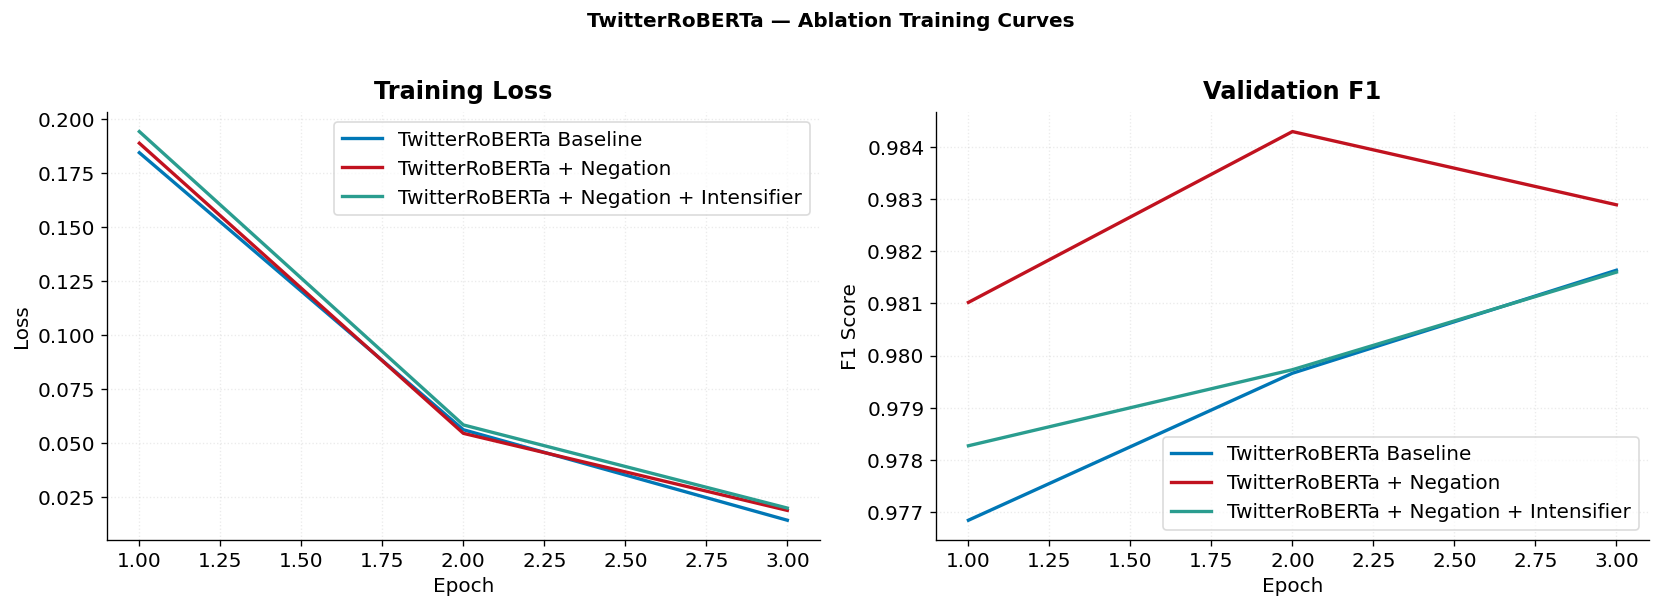

In [ ]:
# Ablation training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 
colors = ['#0077B6', '#C1121F', '#2A9D8F']

for hist, name, c in zip(
    [hist_base, hist_neg, hist_full],
    [name_base, name_neg, name_full],
    colors
):
    axes[0].plot(
        hist['epoch'],
        hist['train_loss'],
        label=name,
        color=c,
        linewidth=2
    )

    axes[1].plot(
        hist['epoch'],
        hist['val_f1'],
        label=name,
        color=c,
        linewidth=2
    )

for ax, title, ylabel in zip(
    axes,
    ['Training Loss', 'Validation F1'],
    ['Loss', 'F1 Score']
):
    ax.set_title(title, fontweight='bold', pad=8)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(framealpha=0.7)

plt.suptitle(
    'TwitterRoBERTa — Ablation Training Curves',
    fontsize=12,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.savefig(
    TWITTERROBERTA_PLT_DIR / 'training_curves.png',
    bbox_inches='tight'
)
plt.show()

## Ablation Confusion Matrices

These matrices provide a detailed view of prediction outcomes for each configuration. They highlight how well the model distinguishes between classes and where misclassifications occur.

Comparing across experiments helps identify improvements in reducing false positives and false negatives.

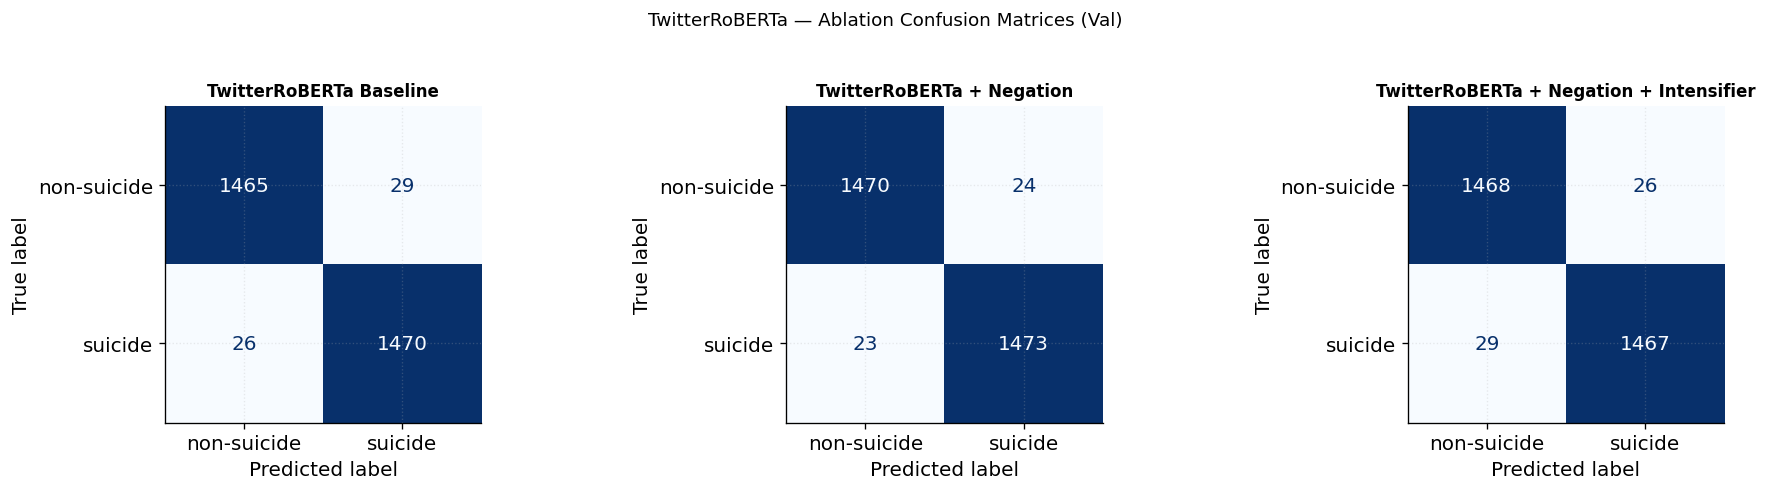

In [ ]:
# Confusion matrices for ablation comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, name, m in zip(
    axes,
    [name_base, name_neg, name_full],
    [val_base, val_neg, val_full]
):
    ConfusionMatrixDisplay(
        confusion_matrix(m['labels'], m['preds']),
        display_labels=['non-suicide', 'suicide']
    ).plot(
        ax=ax,
        colorbar=False,
        cmap='Blues'
    )

    ax.set_title(
        name,
        fontweight='bold',
        fontsize=10
    )

plt.suptitle(
    'TwitterRoBERTa — Ablation Confusion Matrices (Val)',
    fontsize=11,
    y=1.02
)
plt.tight_layout()
plt.savefig(
    TWITTERROBERTA_PLT_DIR / 'ablation_cm.png',
    bbox_inches='tight'
)
plt.show()

## Best Model Selection and Test Evaluation

The best-performing configuration is selected based on validation F1-score. This ensures that the chosen model balances precision and recall effectively.

The selected model is then evaluated on the test set to obtain unbiased performance estimates. Predictions and probabilities are stored for reproducibility, and results are saved for further analysis.

In [ ]:
# Select best experiment based on validation F1
best_idx = ablation_df['F1'].idxmax()
best_condition = ablation_df.loc[best_idx, 'Experiment']

print(f'Best condition: {best_condition}')

# Map experiment to corresponding model and configuration
best_map = {
    name_base: (model_base, 'text_clean', False),
    name_neg:  (model_neg,  'text_neg_tagged', False),
    name_full: (model_full, 'text_neg_tagged', True)
}

bm, bc, bi = best_map[best_condition]

# Prepare test dataset
test_ds = SuicideDataset(
    test,
    tokenizer,
    text_col=bc,
    max_length=MAX_LENGTH,
    use_intensifier=bi
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE * 2,
    collate_fn=collator
)

# Evaluate on test set
test_metrics = evaluate_epoch(
    bm,
    test_loader,
    nn.CrossEntropyLoss(),
    DEVICE
)

# Print classification report
print(classification_report(
    test_metrics['labels'],
    test_metrics['preds'],
    target_names=['non-suicide', 'suicide']
))

# Save predictions and results
with open(TWITTERROBERTA_PREDS_PKL, 'wb') as f:
    pickle.dump({
        'ablation': ablation_df,
        'test_preds': test_metrics['preds'],
        'test_labels': test_metrics['labels'],
        'test_probs': test_metrics['probs'],
        'best_condition': best_condition
    }, f)

ablation_df.to_csv(TWITTERROBERTA_RESULTS_CSV, index=False)

Best condition: TwitterRoBERTa + Negation
              precision    recall  f1-score   support

 non-suicide       0.98      0.99      0.98      1498
     suicide       0.99      0.98      0.98      1500

    accuracy                           0.98      2998
   macro avg       0.98      0.98      0.98      2998
weighted avg       0.98      0.98      0.98      2998

